In [1]:
# Task 1

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
columns = ['Age','Gender','Total_Bilirubin','Direct_Bilirubin','Alkaline_Phosphotase','Alamine_Aminotransferase','Aspartate_Aminotransferase','Total_Proteins','Albumin','Albumin_and_Globulin_Ratio','Dataset']
df = pd.read_csv("Indian Liver Patient Dataset (ILPD).csv", names = columns)

In [4]:
features_to_analyze = ['Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase']
print("--- Statistical Properties of Bilirubin & Liver Enzymes ---")
print(df[features_to_analyze].describe())

--- Statistical Properties of Bilirubin & Liver Enzymes ---
       Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
count       583.000000        583.000000            583.000000   
mean          3.298799          1.486106            290.576329   
std           6.209522          2.808498            242.937989   
min           0.400000          0.100000             63.000000   
25%           0.800000          0.200000            175.500000   
50%           1.000000          0.300000            208.000000   
75%           2.600000          1.300000            298.000000   
max          75.000000         19.700000           2110.000000   

       Alamine_Aminotransferase  Aspartate_Aminotransferase  
count                583.000000                  583.000000  
mean                  80.713551                  109.910806  
std                  182.620356                  288.918529  
min                   10.000000                   10.000000  
25%                   23.000000    

In [5]:
# Encode 'Gender' numerically so it can be used in correlation calculations (Female=0, Male=1)
df['Gender_Encoded'] = df['Gender'].map({'Female':0, 'Male':1})

In [6]:
# Histograms for numerical attributes
fig, ax = plt.subplots(figsize=(15,20))
df.drop(['Gender', 'Gender_Encoded'], axis=1).hist(bins=20, ax=ax, edgecolor='black')
plt.suptitle('Histograms of Dataset Features', fontsize = 16)
plt.tight_layout()
plt.savefig('histograms.png')
plt.close('all')

C:\Users\TUSHAR\AppData\Local\Temp\ipykernel_29340\4178515287.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.drop(['Gender', 'Gender_Encoded'], axis=1).hist(bins=20, ax=ax, edgecolor='black')


In [7]:
# 2. Boxplots (Separated due to different numerical scales)
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['Total_Bilirubin','Direct_Bilirubin']])
plt.title('Boxplot of Bilirubin Levels')
plt.savefig('boxplot_bilirubin.png')
plt.close('all')

plt.figure(figsize=(12,6))
sns.boxplot(data=df[['Alkaline_Phosphotase','Alamine_Aminotransferase','Aspartate_Aminotransferase']])
plt.title('Boxplot of Liver Enzymes')
plt.savefig('boxplot_enzymes.png')
plt.close('all')

In [8]:
# 3. Correlation Heatmap
plt.figure(figsize=(12, 8))
corr_matrix = df.drop('Gender', axis=1).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.close('all')

In [9]:
print("\n--- Correlations with Target Label (Dataset) ---")
print(corr_matrix['Dataset'].sort_values(ascending=True))


--- Correlations with Target Label (Dataset) ---
Direct_Bilirubin             -0.246046
Total_Bilirubin              -0.220208
Alkaline_Phosphotase         -0.184866
Alamine_Aminotransferase     -0.163416
Aspartate_Aminotransferase   -0.151934
Age                          -0.137351
Gender_Encoded               -0.082416
Total_Proteins                0.035008
Albumin                       0.161388
Albumin_and_Globulin_Ratio    0.163131
Dataset                       1.000000
Name: Dataset, dtype: float64


In [10]:
# Task 2

In [11]:
# Task 2c. Encode categorical features
df['Gender'] = df['Gender'].map({'Female':0, 'Male':1})
X = df.drop('Dataset', axis=1)
y = df['Dataset']

In [12]:
# Task 2b. Normalize/standardize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
df_scaled = X_scaled_df.copy()
df_scaled['Dataset'] = y.values
print("--- Class Distribution BEFORE handling imbalance ---")
print(df_scaled['Dataset'].value_counts())

--- Class Distribution BEFORE handling imbalance ---
Dataset
1    416
2    167
Name: count, dtype: int64


In [13]:
from sklearn.utils import resample

df_majority = df_scaled[df_scaled['Dataset'] == 1]
df_minority = df_scaled[df_scaled['Dataset'] == 2]

df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42)
df_resampled = pd.concat([df_majority, df_minority_upsampled])

print("\n--- Class Distribution AFTER handling imbalance ---")
print(df_resampled['Dataset'].value_counts())

df_resampled.to_csv("ILPD_processed.csv", index=False)
print("\nSuccess: Processed dataset saved to 'ILPD_processed.csv'")


--- Class Distribution AFTER handling imbalance ---
Dataset
1    416
2    416
Name: count, dtype: int64

Success: Processed dataset saved to 'ILPD_processed.csv'


In [14]:
# Task 3

--- Random Forest Feature Importance Scores ---
                   Feature  Importance
      Alkaline_Phosphotase    0.181691
Aspartate_Aminotransferase    0.117042
                       Age    0.112952
  Alamine_Aminotransferase    0.112290
           Total_Bilirubin    0.108937
          Direct_Bilirubin    0.101813
            Total_Proteins    0.084978
                   Albumin    0.079370
Albumin_and_Globulin_Ratio    0.075210
                    Gender    0.013432
            Gender_Encoded    0.012286




C:\Users\TUSHAR\AppData\Local\Temp\ipykernel_29340\815190760.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


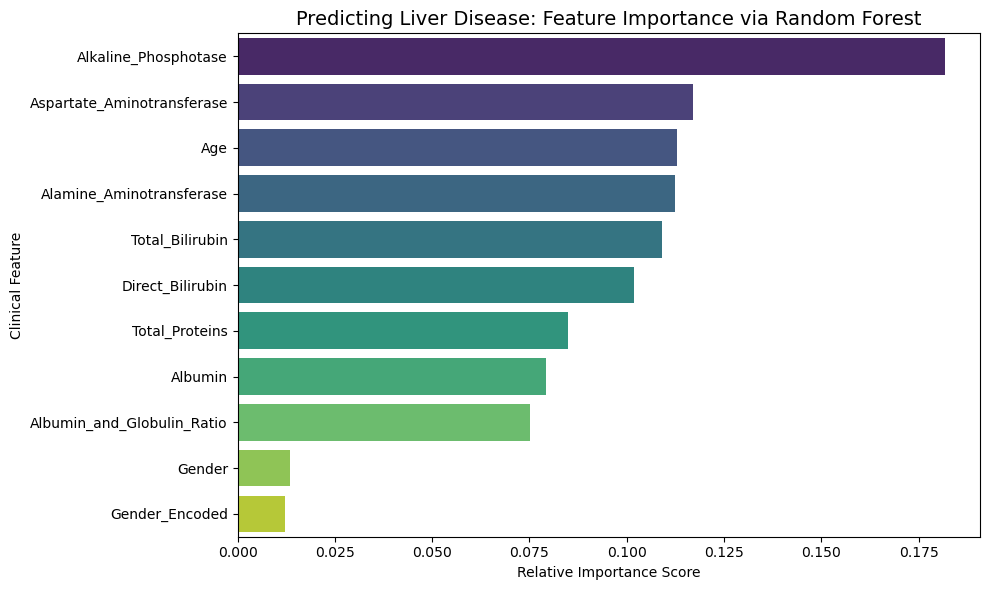

--- Recommended Features to Keep (Importance > 0.05) ---
['Alkaline_Phosphotase', 'Aspartate_Aminotransferase', 'Age', 'Alamine_Aminotransferase', 'Total_Bilirubin', 'Direct_Bilirubin', 'Total_Proteins', 'Albumin', 'Albumin_and_Globulin_Ratio']


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# --- 1. Load the pre-processed dataset ---
df_processed = pd.read_csv("ILPD_processed.csv")

# Just as a safety net: if any NaNs somehow slipped into the CSV, fill them
if df_processed.isnull().sum().sum() > 0:
    df_processed.fillna(df_processed.median(), inplace=True)

# --- 2. Separate features and target ---
X_processed = df_processed.drop('Dataset', axis=1)
y_processed = df_processed['Dataset']

# --- 3. Initialize and train the Random Forest Classifier ---
# Using random_state=42 ensures the exact same random decisions every time
rf_selector = RandomForestClassifier(random_state=42)
rf_selector.fit(X_processed, y_processed)

# --- 4. Extract and sort feature importances ---
importances = rf_selector.feature_importances_
feature_names = X_processed.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort from most important to least important
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("--- Random Forest Feature Importance Scores ---")
print(feature_importance_df.to_string(index=False))
print("\n")

# --- 5. Visualize the feature importances ---
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Predicting Liver Disease: Feature Importance via Random Forest', fontsize=14)
plt.xlabel('Relative Importance Score')
plt.ylabel('Clinical Feature')
plt.tight_layout()
plt.show()

# --- 6. Identify Key Predictors ---
# We can clearly see 'Gender' has the lowest impact, meaning we can drop it in Task 4!
top_features = feature_importance_df[feature_importance_df['Importance'] > 0.05]['Feature'].tolist()

print(f"--- Recommended Features to Keep (Importance > 0.05) ---")
print(top_features)
X_selected = X_processed[top_features]

In [16]:
# Task 4

In [17]:
# pip install xgboost

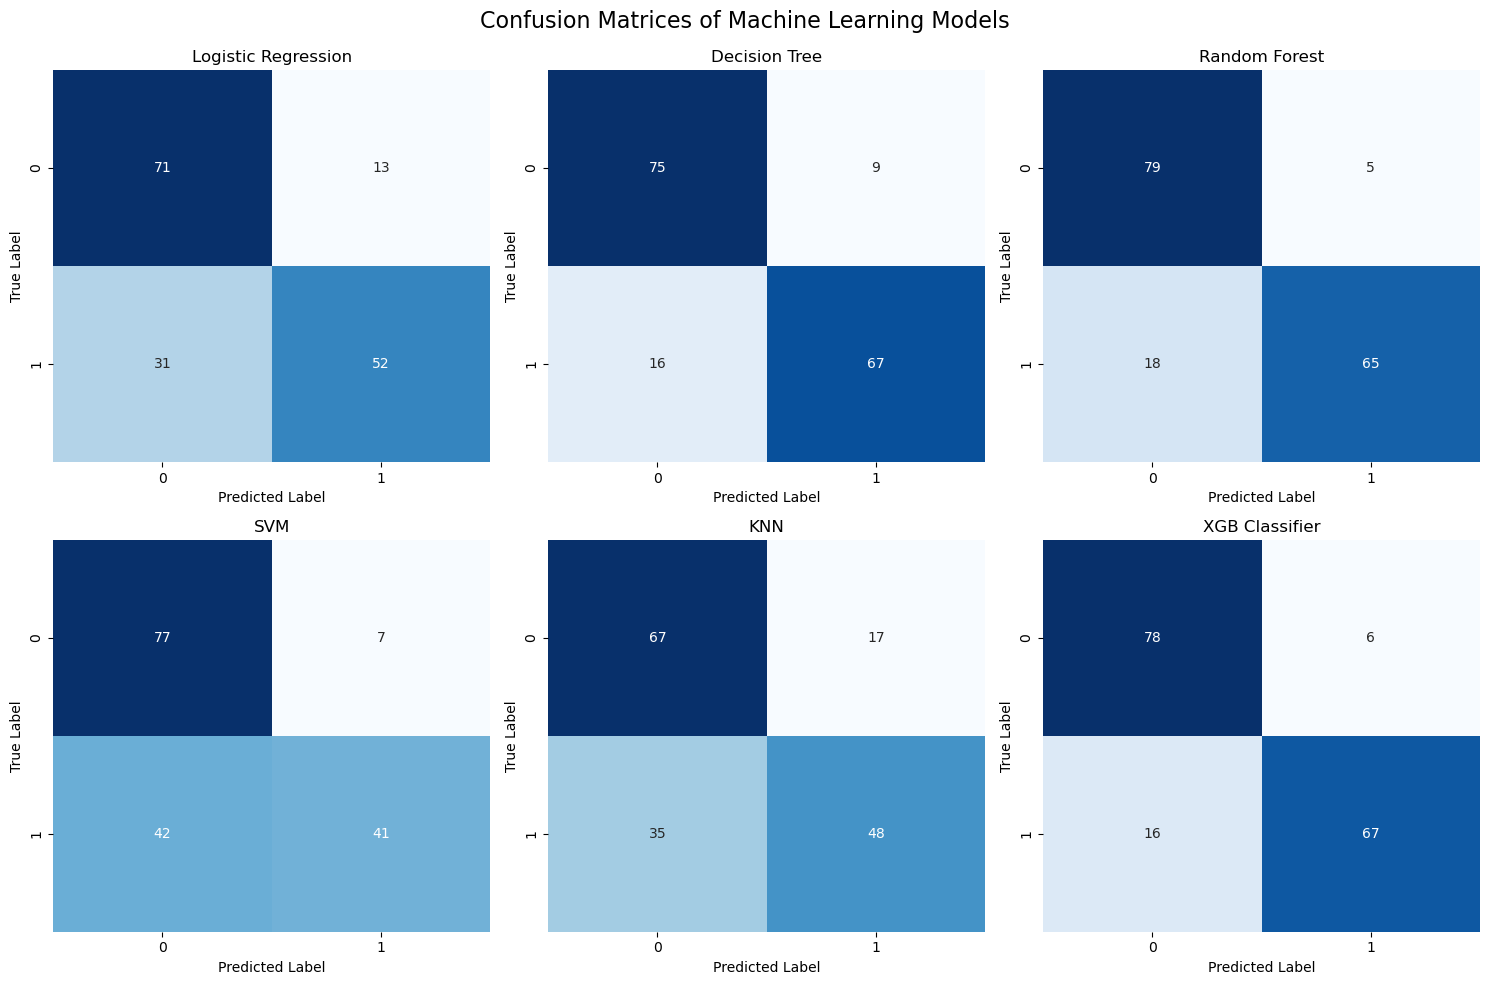

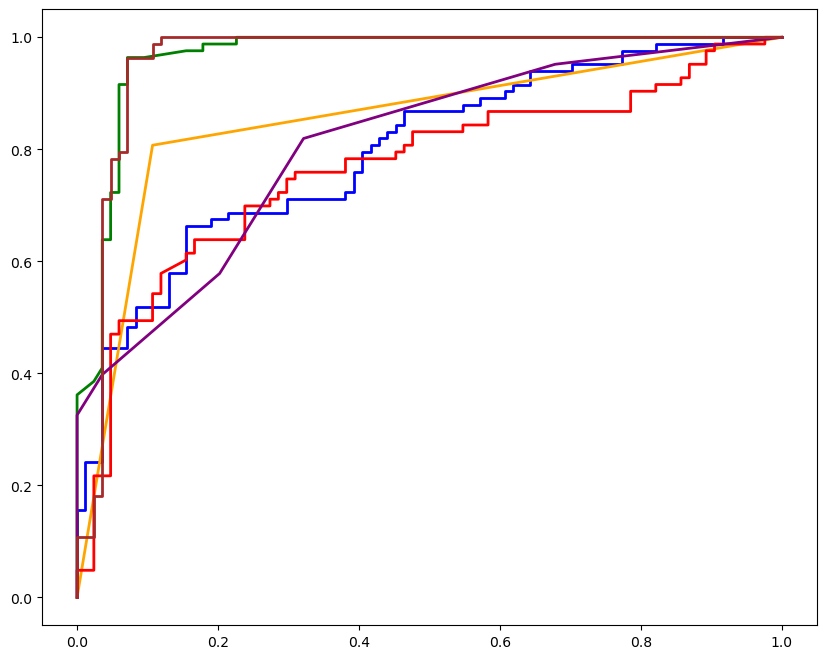


--- Model Performance Comparison Table ---
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.736527   0.800000 0.626506  0.702703
      Decision Tree  0.850299   0.881579 0.807229  0.842767
      Random Forest  0.862275   0.928571 0.783133  0.849673
                SVM  0.706587   0.854167 0.493976  0.625954
                KNN  0.688623   0.738462 0.578313  0.648649
     XGB Classifier  0.868263   0.917808 0.807229  0.858974


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Handle XGBoost import just in case it isn't installed in your environment
try:
    from xgboost import XGBClassifier
except ImportError:
    from sklearn.ensemble import HistGradientBoostingClassifier as XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

# Safety net: fill any unexpected NaNs
if df_processed.isnull().sum().sum() > 0:
    df_processed.fillna(df_processed.median(), inplace=True)

# --- 2. Data Preparation ---
# Map target variable for standard binary classification: 2 (Healthy) = 0, 1 (Liver Patient) = 1
# This is mathematically required for accurate ROC/AUC calculations
df_processed['Dataset'] = df_processed['Dataset'].map({2: 0, 1: 1})

# Drop the target column and the 'Gender' feature (as identified in Task 3)
X_final = df_processed.drop(['Dataset', 'Gender'], axis=1) 
y_final = df_processed['Dataset']

# Split Data (80% Train, 20% Test) - stratify ensures the 50/50 balance is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# --- 3. Initialize Models ---
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42), # probability=True is needed for ROC
    "KNN": KNeighborsClassifier(),
    "XGB Classifier": XGBClassifier(random_state=42) 
}

# --- 4. Train, Evaluate, and Plot ---
results = []

# Setup figure for Confusion Matrices
fig_cm, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Setup figure for ROC Curves
plt.figure(figsize=(10, 8))
roc_ax = plt.gca()

colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

for i, (name, model) in enumerate(models.items()):
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict classes and probabilities
    y_pred = model.predict(X_test)
    
    # Extract probabilities for the positive class (1) for the ROC curve
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1] 
    else:
        y_prob = model.decision_function(X_test)
    
    # Calculate Performance Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1})
    
    # Plot Individual Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')
    
    # Plot Individual ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    roc_ax.plot(fpr, tpr, color=colors[i], lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

# --- 5. Display Final Visuals and Tables ---

# Render Confusion Matrices
fig_cm.suptitle('Confusion Matrices of Machine Learning Models', fontsize=16)
fig_cm.tight_layout()
fig_cm.subplots_adjust(top=0.92)
plt.show()

# Render ROC Curves
roc_ax.plot([0, 1], [0, 1], 'k--', label='Random Guess')
roc_ax.set_xlim([0.0, 1.0])
roc_ax.set_ylim([0.0, 1.05])
roc_ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
roc_ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
roc_ax.set_title('Receiver Operating Characteristic (ROC) Curves', fontsize=16)
# roc_ax.legend(loc="lower right", fontsize=11)
roc_ax.legend(title="Machine Learning Models", loc="lower right", fontsize=11, frameon=True)
roc_ax.grid(alpha=0.3)
plt.show()

# Print Performance Comparison Table
results_df = pd.DataFrame(results)
print("\n--- Model Performance Comparison Table ---")
print(results_df.to_string(index=False))

In [19]:
# Task 5

C:\Users\TUSHAR\AppData\Local\Temp\ipykernel_29340\483343268.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_raw['Albumin_and_Globulin_Ratio'].fillna(df_raw['Albumin_and_Globulin_Ratio'].median(), inplace=True)



--- Starting Hyperparameter Tuning (Grid Search with 5-Fold CV) ---
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Hyperparameters Found: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

--- Impact of Pipeline Stages on Model Performance (Task 5c) ---
                           Stage  Accuracy
          1. Raw Data (Baseline)  0.743590
2. Preprocessed (Scaled + SMOTE)  0.868263
 3. Feature Selected (No Gender)  0.868263
      4. Tuned & Cross-Validated  0.862275


C:\Users\TUSHAR\AppData\Local\Temp\ipykernel_29340\483343268.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Stage', data=comparison_df, palette='magma')


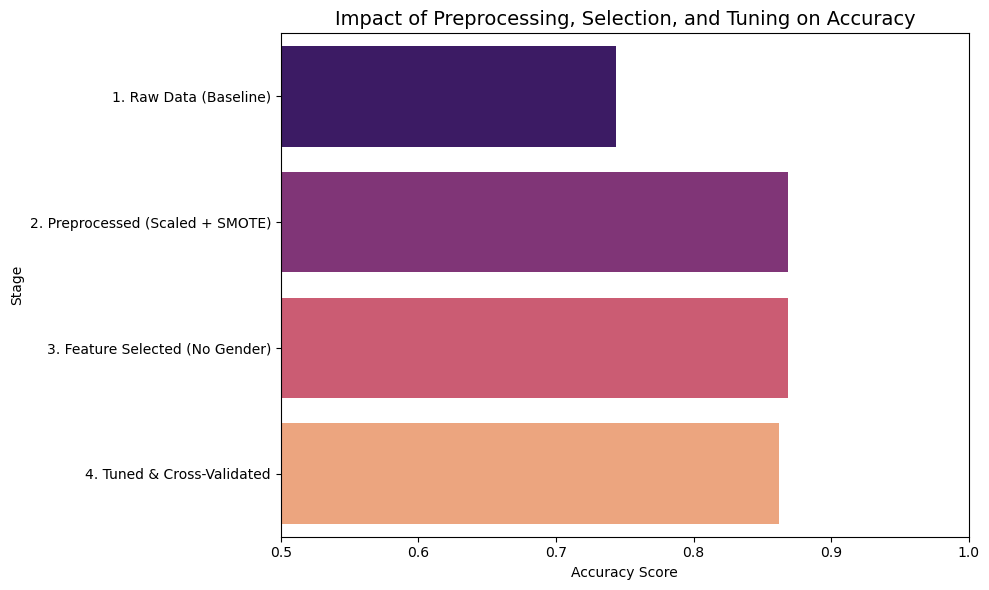

In [20]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# --- Setup for 5c: Compare Pre-processing & Feature Selection Impacts ---
results_comparison = []

# 1. BASELINE: Raw Data (No scaling, missing values, imbalanced)
cols = ['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase',
        'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Proteins',
        'Albumin', 'Albumin_and_Globulin_Ratio', 'Dataset']
df_raw = pd.read_csv("Indian Liver Patient Dataset (ILPD).csv", names=cols)
df_raw['Albumin_and_Globulin_Ratio'].fillna(df_raw['Albumin_and_Globulin_Ratio'].median(), inplace=True)
df_raw['Gender'] = df_raw['Gender'].map({'Female': 0, 'Male': 1})

X_raw = df_raw.drop('Dataset', axis=1)
y_raw = df_raw['Dataset'].map({2: 0, 1: 1})

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

rf_raw = RandomForestClassifier(random_state=42)
rf_raw.fit(X_train_raw, y_train_raw)
acc_raw = accuracy_score(y_test_raw, rf_raw.predict(X_test_raw))
results_comparison.append({"Stage": "1. Raw Data (Baseline)", "Accuracy": acc_raw})


# 2. PREPROCESSED: Scaled & Balanced Data (From Task 2)
df_proc = pd.read_csv("ILPD_processed.csv")
if df_proc.isnull().sum().sum() > 0:
    df_proc.fillna(df_proc.median(), inplace=True)
df_proc['Dataset'] = df_proc['Dataset'].map({2: 0, 1: 1})

X_proc = df_proc.drop('Dataset', axis=1)
y_proc = df_proc['Dataset']

X_train_proc, X_test_proc, y_train_proc, y_test_proc = train_test_split(X_proc, y_proc, test_size=0.2, random_state=42)

rf_proc = RandomForestClassifier(random_state=42)
rf_proc.fit(X_train_proc, y_train_proc)
acc_proc = accuracy_score(y_test_proc, rf_proc.predict(X_test_proc))
results_comparison.append({"Stage": "2. Preprocessed (Scaled + SMOTE)", "Accuracy": acc_proc})


# 3. FEATURE SELECTION: Dropping 'Gender' (From Task 3)
X_sel = df_proc.drop(['Dataset', 'Gender'], axis=1)
y_sel = df_proc['Dataset']

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_sel, y_sel, test_size=0.2, random_state=42)

rf_sel = RandomForestClassifier(random_state=42)
rf_sel.fit(X_train_sel, y_train_sel)
acc_sel = accuracy_score(y_test_sel, rf_sel.predict(X_test_sel))
results_comparison.append({"Stage": "3. Feature Selected (No Gender)", "Accuracy": acc_sel})


# --- Setup for 5a & 5b: Cross-Validation & Hyperparameter Tuning ---

# Define the grid of parameters to test
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV with 5-Fold Cross Validation (cv=5)
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,               # 5-Fold Cross Validation (Task 5a)
    n_jobs=-1,          # Use all processor cores to speed up
    scoring='accuracy',
    verbose=1
)

print("\n--- Starting Hyperparameter Tuning (Grid Search with 5-Fold CV) ---")
grid_search.fit(X_train_sel, y_train_sel)

# Best parameters found by Grid Search
best_params = grid_search.best_params_
print(f"Best Hyperparameters Found: {best_params}")

# 4. FINAL OPTIMIZED MODEL
best_rf = grid_search.best_estimator_
acc_optimized = accuracy_score(y_test_sel, best_rf.predict(X_test_sel))
results_comparison.append({"Stage": "4. Tuned & Cross-Validated", "Accuracy": acc_optimized})

# --- Final Comparison Output ---
print("\n--- Impact of Pipeline Stages on Model Performance (Task 5c) ---")
comparison_df = pd.DataFrame(results_comparison)
print(comparison_df.to_string(index=False))

# Visualize the improvement
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Stage', data=comparison_df, palette='magma')
plt.title('Impact of Preprocessing, Selection, and Tuning on Accuracy', fontsize=14)
plt.xlim(0.5, 1.0) # Zoom in to see the differences clearly
plt.xlabel('Accuracy Score')
plt.tight_layout()
plt.show()

In [21]:
# Visualization

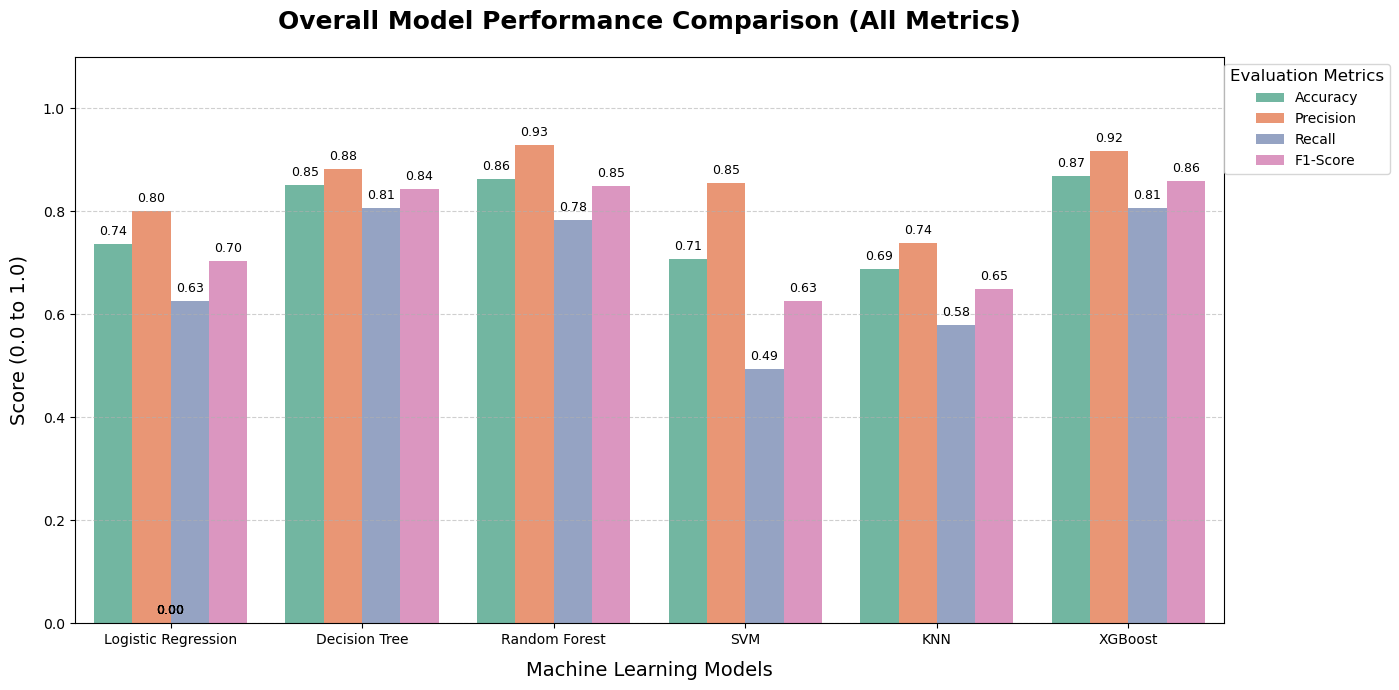


                    FINAL PERFORMANCE TABLE
              Model Accuracy Precision Recall F1-Score
Logistic Regression    73.7%     80.0%  62.7%    70.3%
      Decision Tree    85.0%     88.2%  80.7%    84.3%
      Random Forest    86.2%     92.9%  78.3%    85.0%
                SVM    70.7%     85.4%  49.4%    62.6%
                KNN    68.9%     73.8%  57.8%    64.9%
            XGBoost    86.8%     91.8%  80.7%    85.9%


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
try:
    from xgboost import XGBClassifier
except ImportError:
    from sklearn.ensemble import HistGradientBoostingClassifier as XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --- 1. Quick Data Prep & Model Evaluation ---
df_processed = pd.read_csv("ILPD_processed.csv")
if df_processed.isnull().sum().sum() > 0:
    df_processed.fillna(df_processed.median(), inplace=True)
df_processed['Dataset'] = df_processed['Dataset'].map({2: 0, 1: 1})

X_final = df_processed.drop(['Dataset', 'Gender'], axis=1) 
y_final = df_processed['Dataset']

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42), 
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(random_state=42) 
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "Model": name, 
        "Accuracy": accuracy_score(y_test, y_pred), 
        "Precision": precision_score(y_test, y_pred), 
        "Recall": recall_score(y_test, y_pred), 
        "F1-Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

# --- 2. Visualization: Grouped Bar Chart ---
# "Melt" the dataframe to easily plot it using Seaborn's hue property
df_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(14, 7))
# Create the grouped bar chart
ax = sns.barplot(x="Model", y="Score", hue="Metric", data=df_melted, palette="Set2")

plt.title('Overall Model Performance Comparison (All Metrics)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Machine Learning Models', fontsize=14, labelpad=10)
plt.ylabel('Score (0.0 to 1.0)', fontsize=14, labelpad=10)
plt.ylim(0.0, 1.1) # Set limit slightly above 1 for visual breathing room

# Add the exact numbers on top of each bar for absolute clarity
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=9)

# Format the legend
plt.legend(title='Evaluation Metrics', title_fontsize='12', loc='upper right', bbox_to_anchor=(1.15, 1))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- 3. Visualization: Clean Data Table ---
print("\n" + "="*70)
print(" "*20 + "FINAL PERFORMANCE TABLE")
print("="*70)

# Format floats to percentages for readability in the console
formatted_df = results_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    formatted_df[col] = (formatted_df[col] * 100).map("{:.1f}%".format)

print(formatted_df.to_string(index=False))
print("="*70)

In [23]:
# Use of Explainable AI tools

Generating SHAP Explanations (Global Interpretability)...


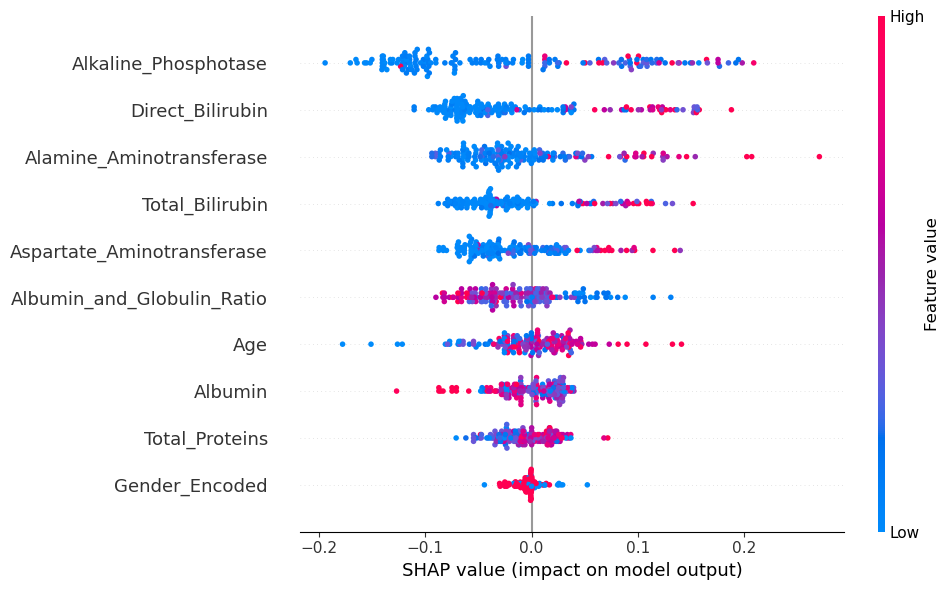


Generating LIME Explanation (Local Interpretability for a single patient)...

Analyzing Patient 0 - True Label: Liver Patient


D:\Anaconda\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
D:\Anaconda\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
D:\Anaconda\Lib\site-packages\lime\lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  binary_column = (

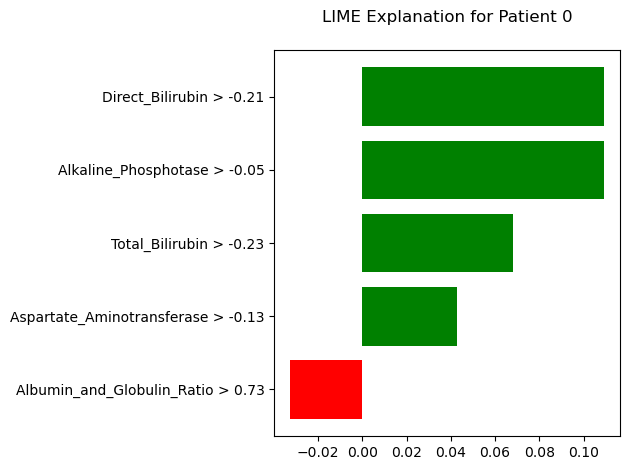


LIME Feature Contributions for this Patient:
Direct_Bilirubin > -0.21: 0.1094
Alkaline_Phosphotase > -0.05: 0.1090
Total_Bilirubin > -0.23: 0.0681
Aspartate_Aminotransferase > -0.13: 0.0427
Albumin_and_Globulin_Ratio > 0.73: -0.0326


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Import Explainable AI Libraries
import shap
import lime
import lime.lime_tabular

# --- 1. Load Data & Train the Model ---
df_processed = pd.read_csv("ILPD_processed.csv")
if df_processed.isnull().sum().sum() > 0:
    df_processed.fillna(df_processed.median(), inplace=True)
df_processed['Dataset'] = df_processed['Dataset'].map({2: 0, 1: 1})

# Define features (Drop 'Gender' based on Task 3)
X = df_processed.drop(['Dataset', 'Gender'], axis=1)
y = df_processed['Dataset']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train a Random Forest model for interpretation
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# ==========================================
# 2. Global Explanation using SHAP (FIXED)
# ==========================================
print("Generating SHAP Explanations (Global Interpretability)...")

# Initialize the SHAP TreeExplainer
shap_explainer = shap.TreeExplainer(model)
shap_values = shap_explainer.shap_values(X_test)

# Handle different versions of the SHAP library output safely
if isinstance(shap_values, list):
    # Older SHAP versions return a list of arrays [Class_0, Class_1]
    shap_vals_positive_class = shap_values[1]
elif len(np.shape(shap_values)) == 3:
    # Newer SHAP versions might return a 3D numpy array (samples, features, classes)
    shap_vals_positive_class = shap_values[:, :, 1]
else:
    # Fallback
    shap_vals_positive_class = shap_values

# IMPORTANT FIX: Do NOT create a plt.figure() manually before this line. 
# Let SHAP control the plot rendering directly!
shap.summary_plot(shap_vals_positive_class, X_test, plot_size=(10, 6), show=True)

# ==========================================
# 3. Local Explanation using LIME
# ==========================================
print("\nGenerating LIME Explanation (Local Interpretability for a single patient)...")

# Initialize the LIME Tabular Explainer with the training data distribution
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=['Healthy', 'Liver Patient'],
    mode='classification',
    random_state=42
)

# Select a single patient to explain (e.g., the very first patient in the test set)
patient_index = 0
single_patient_data = X_test.iloc[patient_index]
true_label = y_test.iloc[patient_index]

print(f"\nAnalyzing Patient {patient_index} - True Label: {'Liver Patient' if true_label == 1 else 'Healthy'}")

# Generate the explanation for why the model predicted what it did for this specific patient
lime_exp = lime_explainer.explain_instance(
    data_row=single_patient_data, 
    predict_fn=model.predict_proba, 
    num_features=5 # Show the top 5 contributing features
)

# Display the LIME plot
fig = lime_exp.as_pyplot_figure()
plt.title(f"LIME Explanation for Patient {patient_index}", pad=20)
plt.tight_layout()
plt.show()

# You can also print the explanation in text format
print("\nLIME Feature Contributions for this Patient:")
for feature, weight in lime_exp.as_list():
    print(f"{feature}: {weight:.4f}")